# Monte Carlo Methods in Inference

<a target="_blank" href="https://colab.research.google.com/github/JunyoungB/statistical-computing-public/blob/main/ch5.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

## Monte Carlo Methods for Estimation

In [1]:
import numpy as np

m = 1000
x = np.random.standard_normal((m, 2))          # m iid pairs
g = np.abs(x[:, 0] - x[:, 1])            # |X1 - X2|
theta_hat = np.mean(g)

# standard error estimate
se_hat = np.sqrt(np.sum((g - np.mean(g)) ** 2)) / m

print(theta_hat)
print(se_hat)

1.1265070501601673
0.0255501392761122


### Monte Carlo Estimation of MSE

In [2]:
n = 20
m = 1000

tmean = np.empty(m)

for i in range(m):
    x = np.sort(np.random.standard_normal(n))
    tmean[i] = np.mean(x[1:-1])          # trim 1 smallest + 1 largest

mse = np.mean(tmean ** 2)

# standard error calculation (as shown in the text)
se_hat = np.sqrt(np.sum((tmean - np.mean(tmean)) ** 2)) / m

print(mse, se_hat)

0.05220489813937681 0.00722517739573265


### Confidence Interval for Variance (Upper Confidence Limit)

In [4]:
from scipy.stats import chi2

n, m = 20, 1000
alpha = 0.05

sigma = 2.0
q = chi2.ppf(alpha, df=n - 1)

def ucl_variance(x: np.ndarray) -> float:
    s2 = np.var(x, ddof=1)                 # sample variance
    return (n - 1) * s2 / q

UCL = np.array([ucl_variance(np.random.normal(0.0, sigma, size=n)) for _ in range(m)])
cover = np.mean(UCL > sigma**2)
se_hat = np.sqrt(cover * (1.0 - cover) / m)

print(cover, se_hat)

0.941 0.007451107300260817


## Monte Carlo Methods for Hypothesis Tests

### Empirical Type I Error Rate for a One-sided t-test

In [6]:
from scipy.stats import t

n, m = 20, 10000
alpha = 0.05
mu0, sigma = 500.0, 100.0

pvals = np.empty(m)
for j in range(m):
    x = np.random.normal(mu0, sigma, size=n)
    xbar, s = np.mean(x), np.std(x, ddof=1)
    tstat = (xbar - mu0) / (s / np.sqrt(n))
    pvals[j] = 1.0 - t.cdf(tstat, df=n - 1)   # one-sided: P(T >= tstat)

p_hat = np.mean(pvals < alpha)
se_hat = np.sqrt(p_hat * (1.0 - p_hat) / m)

print(p_hat, se_hat)

0.049 0.0021586801523152985


### Skewness Test of Normality

In [7]:
from scipy.stats import norm

def skewness_hat(x):
    xbar = np.mean(x)
    m3 = np.mean((x - xbar) ** 3)
    m2 = np.mean((x - xbar) ** 2)
    return m3 / (m2 ** 1.5)

n_vec = np.array([10, 20, 30, 50, 100, 500])
cv = norm.ppf(0.975, loc=0.0, scale=1) * np.sqrt(6.0 / n_vec)

m = 10000
p_reject = np.empty(len(n_vec))

for i, n in enumerate(n_vec):
    sktests = np.empty(m, dtype=int)
    for j in range(m):
        x = np.random.standard_normal(n)                 # H0: normality
        sktests[j] = int(abs(skewness_hat(x)) >= cv[i])
    p_reject[i] = np.mean(sktests)

print(p_reject)

[0.0125 0.0271 0.0353 0.0394 0.0425 0.049 ]


### Empirical Power Curve

In [9]:
import matplotlib.pyplot as plt

n, m = 20, 1000
alpha = 0.05
mu0, sigma = 500.0, 100.0
mu_grid = np.arange(450.0, 651.0, 10.0)

power = np.empty_like(mu_grid, dtype=float)
for i, mu1 in enumerate(mu_grid):
    # simulate under alternative mu1
    x = np.random.normal(loc=mu1, scale=sigma, size=(m, n))
    xbar = x.mean(axis=1)
    s = x.std(axis=1, ddof=1)
    tstat = (xbar - mu0) / (s / np.sqrt(n))
    pvals = 1.0 - t.cdf(tstat, df=n - 1)           # one-sided
    power[i] = np.mean(pvals <= alpha)
se = np.sqrt(power * (1.0 - power) / m)

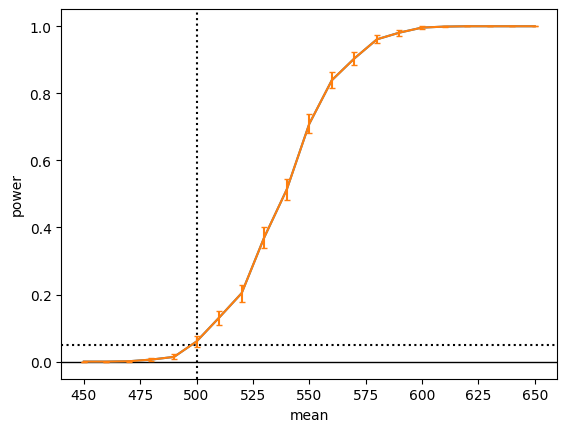

In [14]:
plt.figure()

plt.axhline(0.0, linewidth=1, c="k")
plt.axvline(mu0, linestyle=":", c="k")                   # mu = 500
plt.axhline(alpha, linestyle=":", c="k")                 # alpha = 0.05

plt.plot(mu_grid, power)
plt.errorbar(mu_grid, power, yerr=2.0 * se, capsize=2)

plt.xlabel("mean")
plt.ylabel("power")
#plt.savefig("figs/5-1.png", dpi=160, bbox_inches="tight")
plt.show()

## Application: "Count Five" Test for Equal Variance

### Count Five Statistic

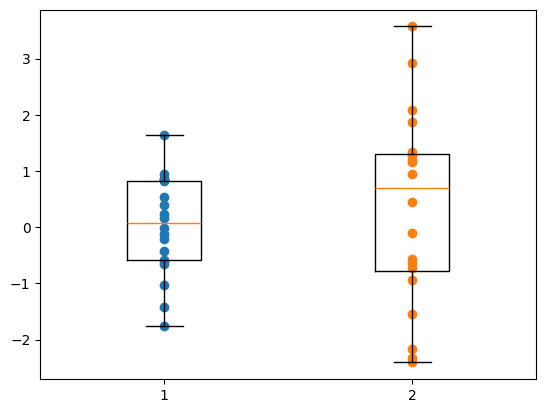

In [17]:
n = 20
x1 = np.random.normal(0.0, 1.0, size=n)
x2 = np.random.normal(0.0, 1.5, size=n)

# side-by-side boxplots with points
plt.figure()
plt.boxplot([x1, x2], widths=0.3)
plt.scatter(np.repeat(1, n), x1)
plt.scatter(np.repeat(2, n), x2)
plt.xlim(0.5, 2.5)

#plt.savefig("figs/5-4.png", dpi=160, bbox_inches="tight")
plt.show()

In [19]:
print(x1.min(), x1.max())
print(x2.min(), x2.max())

# identify extreme points relative to the other sample range
out1 = np.sum(x1 > np.max(x2)) + np.sum(x1 < np.min(x2))
out2 = np.sum(x2 > np.max(x1)) + np.sum(x2 < np.min(x1))
print(max(out1, out2))

-1.7576106115956691 1.6328238258745877
-2.406572797101335 3.572051630778353
7


### Empirical CDF and Quantiles

In [21]:
def maxout(x, y):
    X = x - np.mean(x)
    Y = y - np.mean(y)
    outx = np.sum(X > np.max(Y)) + np.sum(X < np.min(Y))
    outy = np.sum(Y > np.max(X)) + np.sum(Y < np.min(X))
    return int(max(outx, outy))

n1 = n2 = 20
m = 1000

stat = np.empty(m, dtype=int)
for r in range(m):
    x = np.random.normal(0.0, 1.0, size=n1)
    y = np.random.normal(0.0, 1.0, size=n2)
    stat[r] = maxout(x, y)

vals = np.arange(1, stat.max() + 1)
cdf = np.array([(stat <= v).mean() for v in vals])
q80, q90, q95 = np.quantile(stat, [0.8, 0.9, 0.95], method="higher")

print(np.round(cdf,3))
print(q80, q90, q95)

[0.178 0.536 0.753 0.883 0.941 0.971 0.986 0.996 0.999 0.999 1.   ]
4 5 6


### Estimate the Significance Level

In [22]:
n1 = n2 = 20
m = 10000

tests = np.empty(m, dtype=int)
for r in range(m):
    x = np.random.normal(0.0, 1.0, size=n1)
    y = np.random.normal(0.0, 1.0, size=n2)
    tests[r] = int(maxout(x, y) > 5)

alphahat = tests.mean()
se_hat = np.sqrt(alphahat * (1.0 - alphahat) / m)

print(alphahat)
print(se_hat)

0.0538
0.0022562260525044917
